In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive(4).zip to archive(4).zip


In [ ]:
import zipfile

zipfile.ZipFile("/content/archive(4).zip").extractall("/content/")


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
train_dir = "/content/Training"
val_dir = "/content/Validation"

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)


Found 47009 images belonging to 2 classes.
Found 11649 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(16,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1470/1470 ━━━━━━━━━━━━━━━━━━━━ 695s 471ms/step - accuracy: 0.8546 - loss: 0.3210 - val_accuracy: 0.9502 - val_loss: 0.1378
Epoch 2/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 690s 469ms/step - accuracy: 0.9478 - loss: 0.1434 - val_accuracy: 0.9619 - val_loss: 0.1002
Epoch 3/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 678s 461ms/step - accuracy: 0.9585 - loss: 0.1137 - val_accuracy: 0.9611 - val_loss: 0.1055
Epoch 4/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 672s 457ms/step - accuracy: 0.9639 - loss: 0.0982 - val_accuracy: 0.9631 - val_loss: 0.1052
Epoch 5/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 681s 463ms/step - accuracy: 0.9693 - loss: 0.0845 - val_accuracy: 0.9641 - val_loss: 0.1042
Epoch 6/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 686s 467ms/step - accuracy: 0.9763 - loss: 0.0675 - val_accuracy: 0.9646 - val_loss: 0.1009
Epoch 7/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 681s 464ms/step - accuracy: 0.9804 - loss: 0.0535 - val_accuracy: 0.9585 - val_loss: 0.1201
Epoch 8/15
1470/1470 ━━━━━━━━━━━━━━━━━━━━ 677s 461ms/step - accuracy: 0.9

In [ ]:
model.save("gender_model.keras")

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print("Training Accuracy:", acc[-1])
print("Validation Accuracy:", val_acc[-1])


Training Accuracy: 0.9947669506072998
Validation Accuracy: 0.9586230516433716


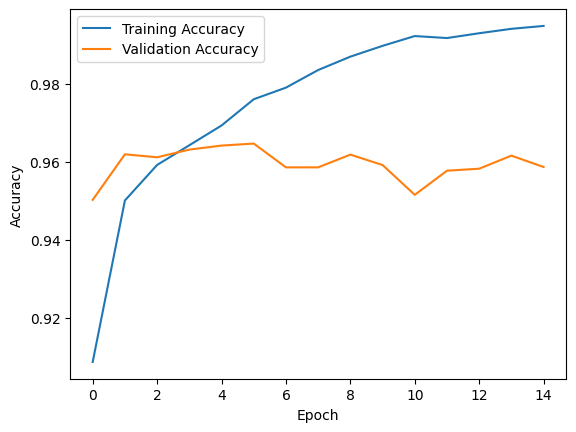

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [ ]:
files.download("gender_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>